In [1]:
import os
import json
from typing import TypedDict
from itertools import islice

import requests
from dotenv import load_dotenv

from openai import OpenAI

from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_experimental.sql import SQLDatabaseChain

from langgraph.graph import END, StateGraph, START

from duckduckgo_search import DDGS

load_dotenv()

/home/onimas/.pyenv/versions/3.11.12/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

response = client.chat.completions.create(
    model="gpt-5.4",
    messages=[{"role": "user", "content": "こんにちは、大阪市の今日はどんな天気ですか？"}],
)

print("Response:", response.choices[0].message.content)

Response: こんにちは。大阪市の今日の天気を確認します。少々お待ちください。


In [6]:
token_used = response.usage
print("Prompt Tokens:", token_used.prompt_tokens)
print("Completion Tokens:", token_used.completion_tokens)
print("Total Tokens:", token_used.total_tokens)
print("Completion_tokens_details:", token_used.completion_tokens_details)
print("Prompt_tokens_details:", token_used.prompt_tokens_details)

Prompt Tokens: 19
Completion Tokens: 121
Total Tokens: 140
Completion_tokens_details: CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0)
Prompt_tokens_details: PromptTokensDetails(audio_tokens=0, cached_tokens=0)


In [7]:
response = client.chat.completions.create(
    model="gpt-5-mini",
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "system",
            "content": "あなたはjsonを出力するように設計された便利なアシスタントです",
        },
        {"role": "assistant", "content": '{"winner": String}'},
        {"role": "user", "content": "2020年のワールドシリーズの優勝者は誰ですか？"},
    ]
)

response.choices[0].message.content

'{"winner":"ロサンゼルス・ドジャース"}'

In [15]:
class Recipe(BaseModel):
    name: str
    servings: int
    ingredients: list[str]
    steps: list[str]

response = client.beta.chat.completions.parse(
    model="gpt-4o",
    messages=[{"role": "user", "content": "たこ焼きのレシピを教えてください"}],
    temperature=0,
    response_format=Recipe
)
recipe = response.choices[0].message.parsed

print("Recipe Name:", recipe.name)
print("Servings:", recipe.servings)
print("Ingredients:", recipe.ingredients)
print("Steps:", recipe.steps)

Recipe Name: たこ焼き
Servings: 4
Ingredients: ['たこ (茹でたもの) - 100g', 'たこ焼き粉 - 200g', '水 - 600ml', '卵 - 2個', '青ねぎ (刻んだもの) - 適量', '紅しょうが (刻んだもの) - 適量', '天かす - 適量', 'たこ焼きソース - 適量', 'マヨネーズ - 適量', 'かつお節 - 適量', '青のり - 適量']
Steps: ['たこ焼き粉をボウルに入れ、水を少しずつ加えながら混ぜます。', '卵を加え、さらに混ぜて滑らかな生地を作ります。', 'たこ焼き器を中火で熱し、油を薄く塗ります。', 'たこ焼き器の穴に生地を流し込み、たこ、青ねぎ、紅しょうが、天かすを適量ずつ入れます。', '生地が固まり始めたら、竹串を使ってたこ焼きを回し、丸く形を整えます。', 'たこ焼きが全体的にきつね色になるまで焼きます。', '焼き上がったたこ焼きを皿に盛り付け、たこ焼きソースとマヨネーズをかけます。', '最後にかつお節と青のりを振りかけて完成です。']


In [17]:
def get_weather(location):
    weather_info = {
        "Tokyo": "晴れ、気温25度",
        "Osaka": "曇り、気温22度",
        "Kyoto": "雨、気温18度",
    }
    return weather_info.get(location, "天気情報が見つかりません")

messages = [{"role": "user", "content": "大阪の天気を教えてください"}]

tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "指定された場所の天気情報を取得します",
            "parameters": {
                "type": "object",
                "properties": {
                    "location": {
                        "type": "string",
                        "description": "都市名(例：Osaka)",
                    }
                },
                "required": ["location"]
            }
        }
    }
]

response = client.chat.completions.create(
    model="gpt-5",
    messages=messages,
    tools=tools,
    tool_choice="auto"
)

response_message = response.choices[0].message
messages.append(response_message)

print("モデルからの応答:")
print(response_message)

if response_message.tool_calls:
    for tool_call in response_message.tool_calls:
        if tool_call.function.name == "get_weather":
            function_args = json.loads(tool_call.function.arguments)
            print(f"関数の引数: {function_args}")
            weather_response = get_weather(location=function_args.get("location"))
            messages.append(
                {
                    "tool_call_id": tool_call.id,
                    "role": "tool",
                    "name": "get_weather",
                    "content": weather_response
                }
            )
else:
    print("モデルによるツール呼び出しはありませんでした")

final_response = client.chat.completions.create(
    model="gpt-5",
    messages=messages
)

print("Final Response:", final_response.choices[0].message.content)

モデルからの応答:
ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_RKLvTL6f8Efn4qnwivigNUiT', function=Function(arguments='{"location":"Osaka"}', name='get_weather'), type='function')])
関数の引数: {'location': 'Osaka'}
Final Response: 大阪の現在の天気は曇り、気温は22℃です。予報もお伝えしましょうか？


In [19]:
class DDGSearchInput(BaseModel):
    """検索クエリが文字列であることをバリデーションします。
    文字列以外のデータ型の検索入力を受け付けません。
    """
    query: str = Field(description="検索キーワードを入力してください")

@tool(args_schema=DDGSearchInput)
def duckduckgo_search(query: str, max_result_num: int = 5) -> list[dict[str, str]]:
    with DDGS() as ddgs:
        response = ddgs.text(query, region="jp-jp", safesearch="off", backend="lite")
        return [
            {
                "title": r.get("title", ""),
                "snippet": r.get("body", ""),
                "url": r.get("href", "")
            }
            for r in islice(response, max_result_num)
        ]

In [21]:
search_query = "About Japan"
search_results = duckduckgo_search.func(query=search_query, max_result_num=3)

print("\n検索結果:")
for i, result in enumerate(search_results):
    print(f"\n{i+1}, {result['title']}")
    print(f"  概要: {result['snippet'][:100]}...")
    print(f"  URL: {result['url']}")

if search_results:
    url = search_results[0]["url"]
    print(f"\n最初の検索結果のURLにアクセスしています: {url}")

    try:
        response = requests.get(url)
        html_content = response.content
        print(f"\nHTTPステータスコード: {response.status_code}")
        print(f"\nHTMLコンテンツの大きさ: {len(html_content)} bytes")
        print(f"\nHTMLコンテンツの最初の部分: \n{html_content[:500]}...")
    except Exception as e:
        print(f"\nエラーが発生しました: {e}")
else:
    print("\n検索結果はありませんでした")

/tmp/ipykernel_6641/2099372661.py:9: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:



検索結果:

1, Bing homepage quiz : r/MicrosoftRewards - Reddit
  概要: 2021年12月4日 · While these are the right answers and this quiz is still currently bugged, you don't lo...
  URL: https://www.reddit.com/r/MicrosoftRewards/comments/r8qjk5/bing_homepage_quiz/

2, EveryDayBingQuiz - Reddit
  概要: Welcome all of you, here you will get daily answers of Microsoft Rewards (Bing Quiz) like Bing Homep...
  URL: https://www.reddit.com/r/EveryDayBingQuiz/

3, BingHomepageQuiz - Reddit
  概要: Microsoft Bing Homepage daily quiz questions and their answers...
  URL: https://www.reddit.com/r/BingHomepageQuiz/hot/

最初の検索結果のURLにアクセスしています: https://www.reddit.com/r/MicrosoftRewards/comments/r8qjk5/bing_homepage_quiz/

HTTPステータスコード: 200

HTMLコンテンツの大きさ: 464600 bytes

HTMLコンテンツの最初の部分: 
b'\n    <!DOCTYPE html>\n    <html lang="en-US" class="theme-beta" dir="ltr" device="mobile">\n      <head prefix="og: https://ogp.me/ns#">\n        <title>Reddit - The heart of the internet</title>\n        <meta name="viewport" 

In [22]:
import duckdb

In [23]:
conn = duckdb.connect('test.duckdb')

In [24]:
conn.execute(
    """
    SELECT 'データベースの初期化が完了しました。従業員数:' AS message,
    COUNT(*) AS count
    FROM employees;
    """
)

In [25]:
conn.close()

In [31]:
class SQLQueryArgs(BaseModel):
    """引数スキーマを定義"""
    keywords: str

@tool(args_schema=SQLQueryArgs)
def text_to_sql_search(keywords: str):

    try:
        db = SQLDatabase.from_uri("duckdb:///test.duckdb")
        
        llm = ChatOpenAI(
            api_key=os.getenv("OPENAI_API_KEY"),
            model="gpt-5"
        )
        
        db_chain = SQLDatabaseChain(llm=llm, database=db, verbose=True)
        response = db_chain.invoke(keywords)
        return response
    except Exception as e:
        return e

args = {"keywords": "employeeテーブルの情報は何件ありますか？"}
text_to_sql_search.func(**args)

sqlalchemy.exc.ProgrammingError('(_duckdb.CatalogException) Catalog Error: Table with name pg_collation does not exist!\nDid you mean "pg_constraint"?\n\nLINE 6: FROM pg_catalog.pg_collation \n             ^')

In [3]:
class AgentState(TypedDict):
    input: str
    plans: list[str]
    feedback: list[str]
    output: str
    iteration: int

workflow = StateGraph(AgentState)

In [5]:
def plan_node(state: AgentState) -> AgentState:
    plan = f"ブログ記事 「{state['input']}」の作成計画:"
    plans = state.get("plans", [])
    plans.append(
        plan
        + "\n1. イントロダクション\n2. LangGraphの基本概念\n3. シンプルなワークフロー例\n4. まとめ"
    )
    return {**state, "plans": plans}

def generation_node(state: AgentState) -> AgentState:
    iteration = state["iteration"]

    iteration += 1

    plan = state["plans"][-1] if state["plans"] else "計画なし"

    output = f"イテレーション　{iteration} の出力:\n"
    if iteration == 1:
        output += "# LangGraphを用いたエージェントワークフロー構築方法\n\n## はじめに\nLangGraphは、大規模言語モデル(LLM)を使用したエージェントやワークフローを構築するためのフレームワークです。"
    elif iteration == 2:
        output += "## LangGraphの基本概念\n\n1. **状態（State）**: ワークフロー全体で共有される情報\n2. **ノード（Node）**: 処理を行う関数\n3. **エッジ（Edge）**: ノード間の接続と遷移条件"
    elif iteration == 3:
        output += "## LangGraphの実装例\n\n```python\nfrom typing import TypedDict\nfrom langgraph.graph import END, StateGraph, START\n\nclass AgentState(TypedDict):\n    input: str\n    output: str\n```"
    else:
        output += "## まとめ\n\nLangGraphを使うことで、複雑なエージェントの振る舞いを制御しやすくなります。状態管理とワークフローの分離により、メンテナンス性の高いAIアプリケーションが開発可能です。"

    return {**state, "output": output, "iteration": iteration}

def reflection_node(state: AgentState) -> AgentState:
    output = state["output"]
    feedbacks = state.get("feedback", [])

    feedback = f"フィードバック（イテレーション {state['iteration']}）:\n"
    if state["iteration"] == 1:
        feedback += "イントロダクションは良いですが、もう少し具体的な例やメリットを追加するといいでしょう。"
    elif state["iteration"] == 2:
        feedback += (
            "基本概念の説明は分かりやすいです。次はコード例を加えると良いでしょう。"
        )
    elif state["iteration"] == 3:
        feedback += "コード例が示されていますが、もう少し詳しい説明や実行結果があると良いでしょう。"

    feedbacks.append(feedback)

    return {**state, "feedbacks": feedbacks}

workflow.add_node("planner", plan_node)
workflow.add_node("generator", generation_node)
workflow.add_node("refrector", reflection_node)

workflow.add_edge(START, "planner")

def should_continue(state: AgentState):
    if state["iteration"] > 3:
        return END
    return "refrector"

workflow.add_edge("planner", "generator")
workflow.add_conditional_edges("generator", should_continue, ["refrector", END])
workflow.add_edge("refrector", "generator")

app = workflow.compile()

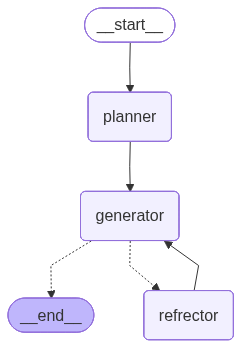

In [6]:
app

In [7]:
inputs = {
    "input": "LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して",
    "iteration": 0,
    "plans": [],
    "feedbacks": [],
    "output": "",
}

for s in app.stream(inputs):
    print(list(s.values())[0])
    print("----")

{'input': 'LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して', 'plans': ['ブログ記事 「LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して」の作成計画:\n1. イントロダクション\n2. LangGraphの基本概念\n3. シンプルなワークフロー例\n4. まとめ'], 'output': '', 'iteration': 0}
----
{'input': 'LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して', 'plans': ['ブログ記事 「LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して」の作成計画:\n1. イントロダクション\n2. LangGraphの基本概念\n3. シンプルなワークフロー例\n4. まとめ'], 'output': 'イテレーション\u30001 の出力:\n# LangGraphを用いたエージェントワークフロー構築方法\n\n## はじめに\nLangGraphは、大規模言語モデル(LLM)を使用したエージェントやワークフローを構築するためのフレームワークです。', 'iteration': 1}
----
{'input': 'LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して', 'plans': ['ブログ記事 「LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して」の作成計画:\n1. イントロダクション\n2. LangGraphの基本概念\n3. シンプルなワークフロー例\n4. まとめ'], 'output': 'イテレーション\u30001 の出力:\n# LangGraphを用いたエージェントワークフロー構築方法\n\n## はじめに\nLangGraphは、大規模言語モデル(LLM)を使用したエージェントやワークフローを構築するためのフレームワークです。', 'iteration': 1}
----
{'input': 'LangGraphを用いたエージェントワークフロー構築方法のブログ記事を作成して', 'plans': ['ブログ記事 「LangGraphを用いたエージェントワークフロー構築方法の

In [8]:
from IPython.display import Image, display

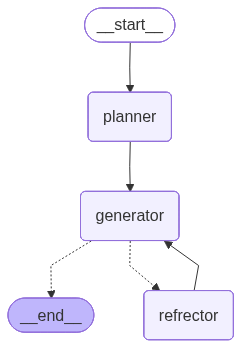

In [9]:
display(Image(app.get_graph().draw_mermaid_png()))